In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import seed
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split


In [287]:
#from __future__ import print_function
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint
from keras.models import model_from_json
from keras import backend as K
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape
from keras.models import Model
from keras import regularizers


In [352]:
inp_file=input("Enter the file name:")

Enter the file name:kdd_test_prep2.csv


In [384]:
encoding_dim=int(input("Enter the features dim:"))

Enter the features dim:16


In [385]:
kdd_FE_prep= pd.read_csv(str(inp_file))


kdd_train_prep=kdd_train[kdd_train["Anomaly"]==-1]
kdd_train_prep.reset_index()
kdd_train_prep.head()

In [386]:
kdd_FE_prep.shape

(22544, 110)

In [387]:
kdd_FE_prep.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack,label_2,label_5
0,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neptune,attack,DoS
1,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neptune,attack,DoS
2,0.000035,2.066513e-04,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,normal,Normal
3,0.000000,3.183413e-07,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,saint,attack,Probe
4,0.000017,0.000000e+00,0.000011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mscan,attack,Probe


In [388]:
label_list=[ 'attack','label_2','label_5']
#label_list=[ 'attack','label_2','label_5']
kdd_FE_label=kdd_FE_prep[label_list]
print(kdd_FE_label.head())
print("kdd_train_label:", kdd_FE_label.shape)

    attack label_2 label_5
0  neptune  attack     DoS
1  neptune  attack     DoS
2   normal  normal  Normal
3    saint  attack   Probe
4    mscan  attack   Probe
kdd_train_label: (22544, 3)


In [389]:
kdd_FE_label.shape

(22544, 3)

In [390]:
kdd_FE_prep.drop(label_list, axis = 1, inplace = True)

In [391]:
kdd_FE_prep.shape

(22544, 107)

In [392]:
# define the number of features
ncol = kdd_FE_prep.shape[1]
print(ncol)

107


#### Split train data into train and validation 70:30 in ratio

In [393]:
X_train, X_val,y_train, y_val = train_test_split(kdd_FE_prep,kdd_FE_label['label_2'], train_size = 0.7, test_size = 0.3, random_state = seed(100))

In [394]:
X_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
20743,0.0,6.525997e-07,0.000097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12843,0.0,4.838788e-06,0.005496,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18760,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14401,0.0,4.600032e-06,0.015695,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6537,0.0,8.754386e-07,0.000040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [395]:
y_train.head()

20743    normal
12843    normal
18760    attack
14401    normal
6537     normal
Name: label_2, dtype: object

In [396]:
X_train.shape

(15780, 107)

In [397]:
X_val.shape

(6764, 107)

In [398]:
### Define the encoder dimension
#encoding_dim = 25


In [399]:
input_dim = Input(shape = (ncol, ))

# Encoder Layers
encoded = Dense(100, activation = 'elu')(input_dim)
encoded = Dense(64, activation = 'elu',activity_regularizer=regularizers.l1(10e-5))(encoded)
encoded = Dense(32, activation = 'elu',activity_regularizer=regularizers.l1(10e-5))(encoded)
encoded = Dense(encoding_dim, activation = 'tanh')(encoded)

# Decoder Layers
decoded = Dense(32, activation = 'elu')(encoded)
decoded = Dense(64, activation = 'elu',activity_regularizer=regularizers.l1(10e-5))(decoded)
decoded = Dense(100, activation = 'elu',activity_regularizer=regularizers.l1(10e-5))(decoded)
decoded = Dense(ncol, activation = 'tanh')(decoded)

# Combine Encoder and Deocder layers
autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
autoencoder.compile(optimizer = 'adam', loss = 'mse')

In [400]:
autoencoder.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_24 (InputLayer)        (None, 107)               0         
_________________________________________________________________
dense_97 (Dense)             (None, 100)               10800     
_________________________________________________________________
dense_98 (Dense)             (None, 64)                6464      
_________________________________________________________________
dense_99 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_100 (Dense)            (None, 16)                528       
_________________________________________________________________
dense_101 (Dense)            (None, 32)                544       
_________________________________________________________________
dense_102 (Dense)            (None, 64)                2112      
__________

### Train Auto Encoder

### epochs= 10 batch_size=50

epochs=10

batch_size=50

autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
autoencoder.compile(optimizer = 'adam', loss = 'mse')
history=autoencoder.fit(X_train, X_train, epochs = epochs, batch_size = batch_size, shuffle = False, validation_data = (X_val, X_val))


loss = history.history['loss']
val_loss = history.history['val_loss']
n_epoch = range(1,epochs+1,1)
plt.figure()
plt.plot(n_epoch, loss, label='Training loss')
plt.plot(n_epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

### epochs= 15 batch_size=50

epochs=15

batch_size=50

autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
autoencoder.compile(optimizer = 'adam', loss = 'mse')
history=autoencoder.fit(X_train, X_train, epochs = epochs, batch_size = batch_size, shuffle = False, validation_data = (X_val, X_val))


loss = history.history['loss']
val_loss = history.history['val_loss']
n_epoch = range(1,epochs+1,1)
plt.figure()
plt.plot(n_epoch, loss, label='Training loss')
plt.plot(n_epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

### epochs= 20 batch_size=50

epochs=20

batch_size=50

autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
autoencoder.compile(optimizer = 'adam', loss = 'mse')
history=autoencoder.fit(X_train, X_train, epochs = epochs, batch_size = batch_size, shuffle = False, validation_data = (X_val, X_val))


loss = history.history['loss']
val_loss = history.history['val_loss']
n_epoch = range(1,epochs+1,1)
plt.figure()
plt.plot(n_epoch, loss, label='Training loss')
plt.plot(n_epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

## FINAL AUTOENCODER

In [401]:
#autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
#autoencoder.compile(optimizer = 'adam', loss = 'mse')
history=autoencoder.fit(X_train, X_train, epochs = 20, batch_size = 100, shuffle = False, validation_data = (X_val, X_val))


Train on 15780 samples, validate on 6764 samples
Epoch 1/20
15780/15780 [==============================] - 2s 151us/step - loss: 0.1152 - val_loss: 0.0629
Epoch 2/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0527 - val_loss: 0.0461
Epoch 3/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0433 - val_loss: 0.0411
Epoch 4/20
15780/15780 [==============================] - 1s 75us/step - loss: 0.0397 - val_loss: 0.0385
Epoch 5/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0376 - val_loss: 0.0366
Epoch 6/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0360 - val_loss: 0.0351
Epoch 7/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0348 - val_loss: 0.0342
Epoch 8/20
15780/15780 [==============================] - 1s 74us/step - loss: 0.0339 - val_loss: 0.0336
Epoch 9/20
15780/15780 [==============================] - 1s 73us/step - loss: 0.0331 - val_loss: 0.0327
Epoch

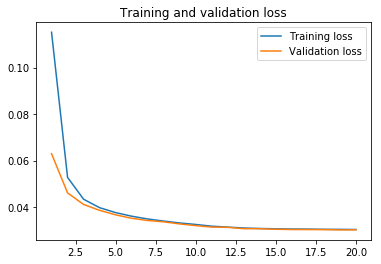

In [402]:
loss = history.history['loss']
val_loss = history.history['val_loss']
n_epoch = range(1,21,1)
plt.figure()
plt.plot(n_epoch, loss, label='Training loss')
plt.plot(n_epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

### Use Encoder level to reduce dimension of train and test data

In [403]:
encoder = Model(inputs = input_dim, outputs = encoded)
encoded_input = Input(shape = (encoding_dim, ))


### Predict the new train and test data using Encoder

In [404]:
encoded_df = pd.DataFrame(encoder.predict(kdd_FE_prep))
encoded_df = encoded_df.add_prefix('feature_')

#encoded_test = pd.DataFrame(encoder.predict(X_test))
#encoded_test = encoded_test.add_prefix('feature_')

In [405]:
encoded_df.shape

(22544, 16)

In [406]:
encoded_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,0.001499,0.000899,-0.000464,-0.000540,-0.000005,-0.000013,-0.000273,0.001356,0.001009,-0.000802,0.000235,-0.000495,-0.001022,0.001489,0.000043,0.000590
1,0.001300,0.000752,-0.000624,-0.000569,0.000140,0.000215,-0.000358,0.001187,0.001027,-0.000965,-0.000038,-0.000299,-0.001023,0.001606,-0.000002,0.000956
2,0.001082,0.000662,-0.000086,0.000411,0.000113,-0.000179,-0.000172,0.000878,-0.000679,-0.000371,-0.000360,-0.000329,-0.001225,0.000614,-0.000561,0.000369
3,0.001347,-0.000114,-0.000248,0.001025,-0.000504,-0.001347,0.000696,0.000721,0.000598,0.000904,0.000979,-0.000842,0.000444,0.001587,0.000114,0.000529
4,0.001028,0.000160,-0.001920,-0.000852,-0.000144,0.000025,-0.000300,0.001142,0.001376,-0.000877,0.000656,-0.000374,0.000226,0.001495,0.000087,0.002681


In [407]:
kdd_FE_label.shape

(22544, 3)

In [408]:
encoded_df = pd.concat([encoded_df,kdd_FE_label], axis = 1)
encoded_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,attack,label_2,label_5
0,0.001499,0.000899,-0.000464,-0.000540,-0.000005,-0.000013,-0.000273,0.001356,0.001009,-0.000802,0.000235,-0.000495,-0.001022,0.001489,0.000043,0.000590,neptune,attack,DoS
1,0.001300,0.000752,-0.000624,-0.000569,0.000140,0.000215,-0.000358,0.001187,0.001027,-0.000965,-0.000038,-0.000299,-0.001023,0.001606,-0.000002,0.000956,neptune,attack,DoS
2,0.001082,0.000662,-0.000086,0.000411,0.000113,-0.000179,-0.000172,0.000878,-0.000679,-0.000371,-0.000360,-0.000329,-0.001225,0.000614,-0.000561,0.000369,normal,normal,Normal
3,0.001347,-0.000114,-0.000248,0.001025,-0.000504,-0.001347,0.000696,0.000721,0.000598,0.000904,0.000979,-0.000842,0.000444,0.001587,0.000114,0.000529,saint,attack,Probe
4,0.001028,0.000160,-0.001920,-0.000852,-0.000144,0.000025,-0.000300,0.001142,0.001376,-0.000877,0.000656,-0.000374,0.000226,0.001495,0.000087,0.002681,mscan,attack,Probe


In [409]:
encoded_df.shape

(22544, 19)

In [410]:
encoded_df.shape

(22544, 19)

In [411]:
encoded_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,attack,label_2,label_5
0,0.001499,0.000899,-0.000464,-0.000540,-0.000005,-0.000013,-0.000273,0.001356,0.001009,-0.000802,0.000235,-0.000495,-0.001022,0.001489,0.000043,0.000590,neptune,attack,DoS
1,0.001300,0.000752,-0.000624,-0.000569,0.000140,0.000215,-0.000358,0.001187,0.001027,-0.000965,-0.000038,-0.000299,-0.001023,0.001606,-0.000002,0.000956,neptune,attack,DoS
2,0.001082,0.000662,-0.000086,0.000411,0.000113,-0.000179,-0.000172,0.000878,-0.000679,-0.000371,-0.000360,-0.000329,-0.001225,0.000614,-0.000561,0.000369,normal,normal,Normal
3,0.001347,-0.000114,-0.000248,0.001025,-0.000504,-0.001347,0.000696,0.000721,0.000598,0.000904,0.000979,-0.000842,0.000444,0.001587,0.000114,0.000529,saint,attack,Probe
4,0.001028,0.000160,-0.001920,-0.000852,-0.000144,0.000025,-0.000300,0.001142,0.001376,-0.000877,0.000656,-0.000374,0.000226,0.001495,0.000087,0.002681,mscan,attack,Probe


In [412]:
out_file=inp_file.split(".")[0] + "_SAE_"+str(encoding_dim)+".csv"

In [413]:
print(out_file)

kdd_test_prep2_SAE_16.csv


In [414]:
encoded_df.to_csv(out_file,index=False)